In [1]:
import os

In [2]:
print(os.getcwd())

C:\Users\paddy


In [3]:
import pandas as pd

In [4]:
import matplotlib.pyplot as plt

In [5]:
import re

In [6]:
raw = pd.read_csv('CPI Inflation 2015=100.csv', header=None, names=["Date", "Value"]) 

In [7]:
is_monthly = raw["Date"].astype(str).str.match(r"^\d{4} [A-Z]{3}$")

In [8]:
cpidata = raw[is_monthly].copy()

In [9]:
cpidata["Date"] = pd.to_datetime(cpidata["Date"], format="%Y %b")

In [10]:
cpidata = cpidata.reset_index(drop=True)

In [11]:
cpidata.head()

,Date,Value
0,1989-01-01,5.7
1,1989-02-01,5.8
2,1989-03-01,5.9
3,1989-04-01,5.6
4,1989-05-01,5.9


In [12]:
irate = pd.read_csv("Interest Rate Data.csv")

In [13]:
irate.columns = ["Date", "Interest Rate"]

In [14]:
irate = irate.dropna(subset=["Date", "Interest Rate"])

In [15]:
irate["Date"] = pd.to_datetime(irate["Date"], format="%d %b %y")

In [16]:
irate = irate.sort_values("Date").reset_index(drop=True)

In [17]:
irate.head()

,Date,Interest Rate
0,1975-01-31,11.00
1,1975-02-28,10.50
2,1975-03-31,10.00
3,1975-04-30,9.75
4,1975-05-31,10.00


In [18]:
rawu = pd.read_csv("Unemployment Rate.csv", header=None, names=["Date", "Unemployment Rate"])

In [19]:
is_monthly = rawu["Date"].astype(str).str.match(r"^\d{4} [A-Z]{3}$")

In [20]:
unemployment = rawu[is_monthly].copy()

In [21]:
unemployment["Date"] = pd.to_datetime(unemployment["Date"], format="%Y %b")

In [22]:
unemployment = unemployment.reset_index(drop=True)

In [23]:
unemployment.head()

,Date,Unemployment Rate
0,1971-02-01,3.8
1,1971-03-01,3.9
2,1971-04-01,4.0
3,1971-05-01,4.1
4,1971-06-01,4.1


In [24]:
unemployment["Date"].dt.month.value_counts().sort_index()

Date
1     55
2     56
3     56
4     56
5     56
6     56
7     55
8     55
9     55
10    55
11    55
12    55
Name: count, dtype: int64

In [25]:
unemployment["Unemployment Rate"].dtype

<StringDtype(na_value=nan)>

In [26]:
unemployment["Unemployment Rate"] = pd.to_numeric(unemployment["Unemployment Rate"], errors="coerce")

In [27]:
cpidata["Date"].dtype

dtype('<M8[us]')

In [28]:
cpidata.head()

,Date,Value
0,1989-01-01,5.7
1,1989-02-01,5.8
2,1989-03-01,5.9
3,1989-04-01,5.6
4,1989-05-01,5.9


In [29]:
unemployment.head()

,Date,Unemployment Rate
0,1971-02-01,3.8
1,1971-03-01,3.9
2,1971-04-01,4.0
3,1971-05-01,4.1
4,1971-06-01,4.1


In [30]:
irate.head()

,Date,Interest Rate
0,1975-01-31,11.00
1,1975-02-28,10.50
2,1975-03-31,10.00
3,1975-04-30,9.75
4,1975-05-31,10.00


In [31]:
cpidata["Date"] = pd.to_datetime(cpidata["Date"], format="%Y %b")

In [32]:
cpidata["YearMonth"] = cpidata["Date"].dt.to_period("M")

In [33]:
cpidata["Value"].dtype

<StringDtype(na_value=nan)>

In [34]:
cpidata["Value"] = pd.to_numeric(cpidata["Value"], errors="coerce")

In [35]:
cpidata = cpidata.sort_values("Date").reset_index(drop=True)
cpidata["YoY Inflation"] = cpidata["Value"].pct_change(periods=12) * 100

In [36]:
unemployment["Date"].dtype

dtype('<M8[us]')

In [37]:
unemployment["YearMonth"] = unemployment["Date"].dt.to_period("M")

In [38]:
irate["YearMonth"] = irate["Date"].dt.to_period("M")

In [39]:
assert cpidata["YearMonth"].is_unique

In [40]:
assert irate["YearMonth"].is_unique

In [41]:
assert unemployment["YearMonth"].is_unique

In [42]:
cpidata["YoY Inflation"] = cpidata["Value"]

In [43]:
panel = (
    cpidata[["YearMonth", "Date", "YoY Inflation"]]
    .merge(irate[["YearMonth", "Interest Rate"]], on="YearMonth", how="inner")
    .merge(unemployment[["YearMonth", "Unemployment Rate"]], on="YearMonth", how="inner")
    .sort_values("YearMonth")
    .reset_index(drop=True)
)

In [44]:
panel.head()

,YearMonth,Date,YoY Inflation,Interest Rate,Unemployment Rate
0,1989-01,1989-01-01,5.7,12.875,7.7
1,1989-02,1989-02-01,5.8,12.875,7.6
2,1989-03,1989-03-01,5.9,12.875,7.4
3,1989-04,1989-04-01,5.6,12.875,7.3
4,1989-05,1989-05-01,5.9,13.750,7.2


In [45]:
import matplotlib.ticker as mticker

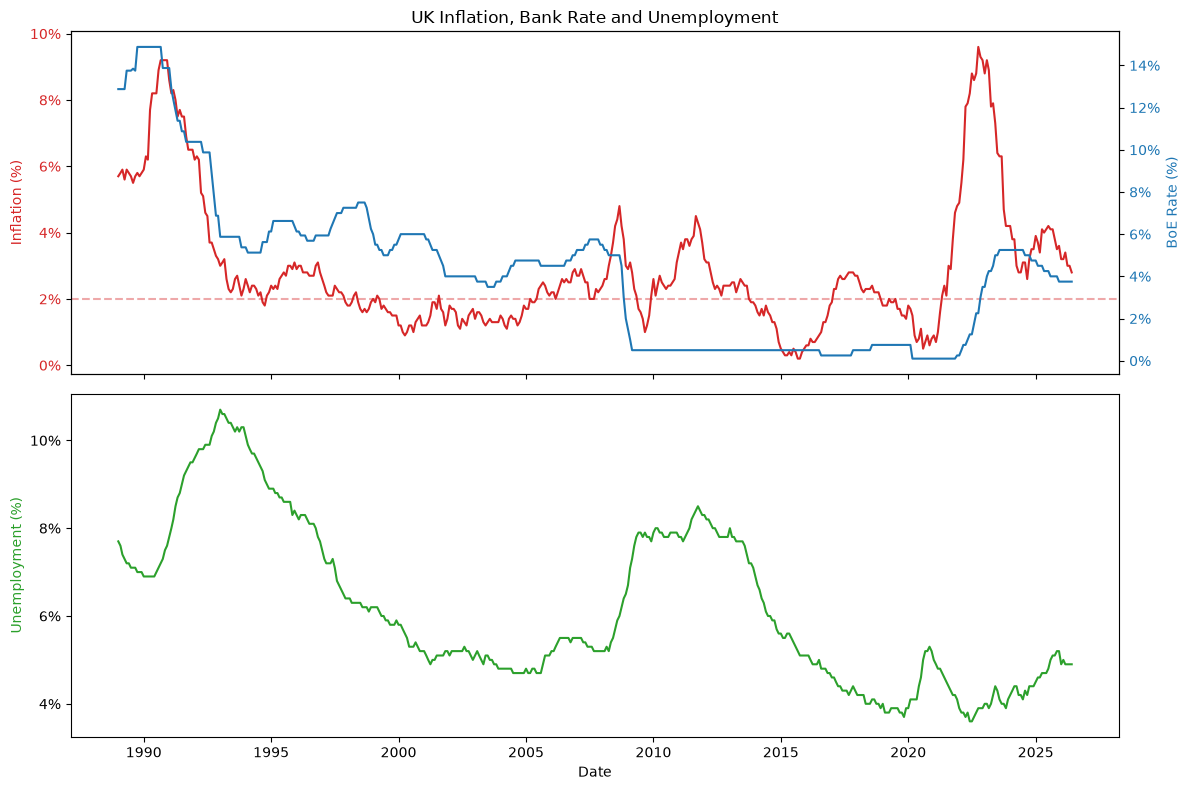

In [46]:
import matplotlib.pyplot as plt


plot_data = panel.dropna(subset=["YoY Inflation", "Interest Rate", "Unemployment Rate"])
plot_data = plot_data.sort_values("Date")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

#Inflation on top panel
ax1.plot(plot_data["Date"], plot_data["YoY Inflation"], color="tab:red", label="CPI Inflation (YoY %)")
ax1.axhline(2, color="tab:red", linestyle="--", alpha=0.4, label="BoE 2% Target")
ax1.set_ylabel("Inflation (%)", color="tab:red")
ax1.tick_params(axis="y", labelcolor="tab:red")

#Interest Rate on top panel
ax1b = ax1.twinx()
ax1b.plot(plot_data["Date"], plot_data["Interest Rate"], color="tab:blue", label="BoE Rate (%)")
ax1b.set_ylabel("BoE Rate (%)", color="tab:blue")
ax1b.tick_params(axis="y", labelcolor="tab:blue")
ax1.set_title("UK Inflation, Bank Rate and Unemployment")

#Unemployment Rate on bottom panel
ax2.plot(plot_data["Date"], plot_data["Unemployment Rate"], color="tab:green", label="Unemployment Rate (%)")
ax2.set_ylabel("Unemployment (%)", color="tab:green")
ax2.set_xlabel("Date")

# clean and readable ticks on all three y-axes
for axis in (ax1, ax1b, ax2):
    axis.yaxis.set_major_locator(mticker.MultipleLocator(2))
    axis.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
    
plot_data["Date"].is_monotonic_increasing   # should be True
plot_data[["YoY Inflation", "Interest Rate", "Unemployment Rate"]].max()   # should show ~9.6, ~14.8, ~9.9

fig.tight_layout()
plt.show()

*Key Takeaways (This was mostly to practise cleaning data and presenting it and I did not use any regression analysis etc to try and estimate relationships.)*

(It should also be noted that most of the assumptions I have stated in regards to relationships between interest, inflation and unemployment rates come form the IS-LM-PC framework which I understand is contested.)

- Observe the Lawson Boom just as our data starts.
- Looks to be a period close to a textbook equilibrium between 1997-2008 with inflation around target and unemployment steady which we could presume means it is close to a natural rate.
- Clear shift post Financial Crash: Approach to Interest Rates seems more dovish post crash.
-  Rates seemed ineffective at dealing with unemployment post crash - roughly 2015
-  Appears as if the bank was slow to react to inflation post pandemic 



Primarily what stood out to me looking at these rates is the shift from pre 2008 financial crash relationships and post. Just observing visually without using any regression analysis, from 1990-2008 inflation appears to react to the rate the central bank set (even if this was an ill-judged one during the Lawson boom) and the level of employment albeit with a delay which could be expected as caused by the delay in transmission of interest rates into prices. Unemployment also follows along moreorless how we would expect according to ISLMPC as taught in classes. We then see inflation drop over the following 1-2 years from 9% to target. As we would expect unemployment spikes following this but the bank brings down rates and from around 1997-2007 there appears to be somewhat of an equilibrium, with inflation rates roughly at target, unemployment rate between 5-6% which we would expect as a natural rate and interest rate held between 3.5-7% to maintain this. 

This all changes following the financial crash, unemployment rockets and the bank slams interest rates down towards the zero lower bound. What we then see is a central bank that has expended the nominal interest rate tool to fight unemployment which stays high just under 8% this explains why the bank engaged in quantitative easing during this period to attempt to stimulate the economy. Inflation then falls down towards to target and close to deflation. Unemployment recovers to pre-crash equilibrium around 2015, despite this the BoE keeps interest rate near zero lower bound. I think this period highlights the limitations of the central banks tools, despite rates being dropped to close to zero lower bound unemployment still stayed well above what we'd expect at equilibrium for a long period until 2015.

We then see the effect of the pandemic. A spike in unemployment presumably during lockdown is then followed by a huge spike in inflation, although at the time this was clearly caused by supply-chain issues and the reduction in output due to the pandemic, the bank did not react with rates until inflation was far above target which I believe could be seen as a mistake. I would say however that this period of time also highlights how interest rates aren't the start and end of inflation as this spike was clearly caused by supply side issues.

Another long term change we seem to observe post financial crash is the BoE taking a more dovish approach relative to pre-2008, where before they were willing to raise rates up to around 15% to bring inflation back to target, now they were lowering rates with inflation nearing 4%. Although the Bank justifies these cuts by saying they are based on forecasted inflation trends it still appears to me to be markedly less hawkish.